# Decisión de Flor — Truco Uruguayo (escenario 1v2)

## Pregunta
Tengo flor (soy el único en mi equipo). Los dos rivales también tienen flor.
**¿A partir de qué puntaje de flor me conviene subir la apuesta?**

## Puntos de flor
Se calculan según las reglas de Truco Uruguayo (distinto de envido):
- 3 piezas: `max_pieza + (2ª_pieza % 10) + (3ª_pieza % 10)`
- 2 piezas + otra: `max_pieza + (2ª_pieza % 10) + pts_carta3`
- 1 pieza + 2 del mismo palo: `pieza + pts_carta2 + pts_carta3`
- Flor derecha (3 del mismo palo): `sum(pts) + 20`

## Análisis de EV (escenario 1v2)
Sea `P` = mi probabilidad de ganar la flor.

| Jugada | EV |
|---|---|
| Pasivo ("la mía es flor") | `3P − 6(1−P) = 9P − 6` |
| Subir (cualquier suba R > 0) | beneficio adicional vs pasivo cuando `P > 1/2` |

**Umbrales:**
- `EV(pasivo) > 0`  ⟺  `P > 2/3`  → mínimo para que el pasivo sea rentable
- `EV(subir) > EV(pasivo)`  ⟺  `P > 1/2`  → conviene subir sobre el pasivo

In [1]:
import sys

sys.path.insert(0, '.')

from experimentos.experimento_flor_decision import EXPERIMENTO

N = 1_000_000
SEED = 42

r = EXPERIMENTO['simulate'](N, SEED)
EXPERIMENTO['report_fn'](r)
print(f"\nManos filtradas (1v2): {r['n_filtradas']:,}")


  P(ganar flor | mis pts de flor == X)  —  escenario 1v2
  n total = 1,000,000   |   manos filtradas = 5,774   |   semilla = 42
     X     Manos    P(ganar)           IC 95%                  SE
  ------------------------------------------------------------------
    20        15        0.0%  [0.0% , 0.0%]     0.00%
    21        44        0.0%  [0.0% , 0.0%]     0.00%
    22        56        0.0%  [0.0% , 0.0%]     0.00%
    23        91        0.0%  [0.0% , 0.0%]     0.00%
    24        86        0.0%  [0.0% , 0.0%]     0.00%
    25       133        0.0%  [0.0% , 0.0%]     0.00%
    26       166        0.0%  [0.0% , 0.0%]     0.00%
    27       282        0.0%  [0.0% , 0.0%]     0.00%
    28       290        1.7%  [0.2% , 3.2%]     0.76%
    29       319        3.1%  [1.2% , 5.0%]     0.98%
    30       380        6.8%  [4.3% , 9.4%]     1.30%
    31       411        9.7%  [6.9% , 12.6%]     1.46%
    32       374        9.6%  [6.6% , 12.6%]     1.53%
    33       432       16.9%  [1

In [2]:
import math

z = 1.96
stats = []

for x in sorted(r['buckets']):
    total, wins = r['buckets'][x]
    if total < 10:
        continue
    p = wins / total
    se = math.sqrt(p * (1 - p) / total)
    lo = max(0.0, p - z * se)
    hi = min(1.0, p + z * se)
    stats.append({'x': x, 'total': total, 'p': p, 'lo': lo, 'hi': hi, 'se': se})

xs   = [s['x']     for s in stats]
ps   = [s['p']     for s in stats]
los  = [s['lo']    for s in stats]
his  = [s['hi']    for s in stats]

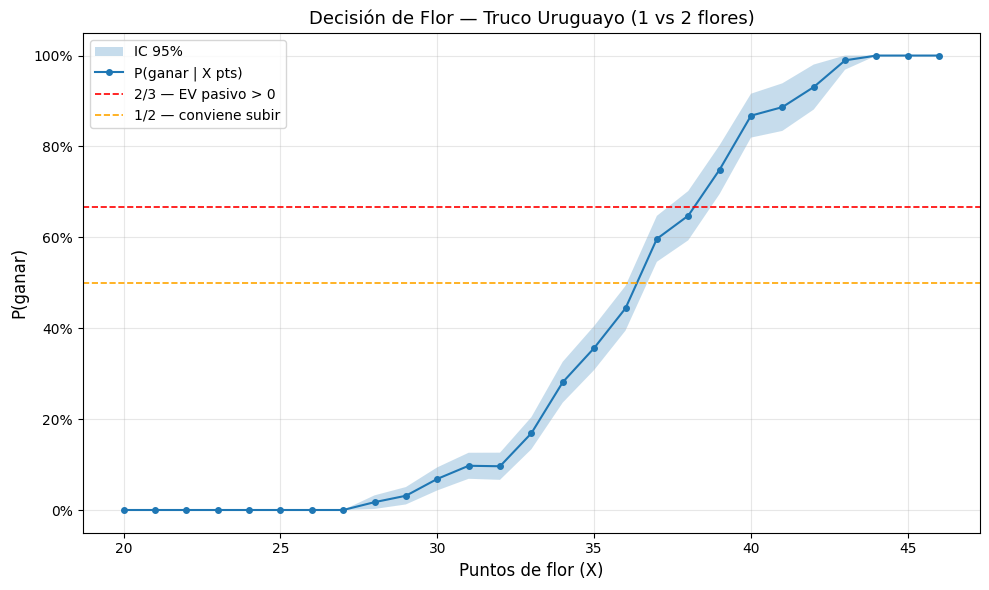

Guardado en plots/decision_flor.png


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(xs, los, his, alpha=0.25, label='IC 95%')
ax.plot(xs, ps, marker='o', markersize=4, label='P(ganar | X pts)')

ax.axhline(2/3, color='red',    linestyle='--', linewidth=1.2, label='2/3 — EV pasivo > 0')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=1.2, label='1/2 — conviene subir')

ax.set_xlabel('Puntos de flor (X)', fontsize=12)
ax.set_ylabel('P(ganar)', fontsize=12)
ax.set_title('Decisión de Flor — Truco Uruguayo (1 vs 2 flores)', fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/decision_flor.png', dpi=150)
plt.show()
print('Guardado en plots/decision_flor.png')

In [4]:
# Cruces de umbral
thresholds = [(2/3, '2/3  (EV pasivo > 0)'), (0.5, '1/2  (conviene subir)')]

print("Mínimo X donde P(ganar | X) ≥ umbral:")
print(f"  {'Umbral':30s}  {'Min X':>6}")
print(f"  {'-'*40}")
for thresh, label in thresholds:
    crossings = [s['x'] for s in stats if s['p'] >= thresh]
    if crossings:
        print(f"  {label:30s}  {crossings[0]:>6}")
    else:
        print(f"  {label:30s}  {'(nunca)':>6}")

Mínimo X donde P(ganar | X) ≥ umbral:
  Umbral                           Min X
  ----------------------------------------
  2/3  (EV pasivo > 0)                39
  1/2  (conviene subir)               37


## Reglas de decisión

Con los resultados de la simulación (n=1.000.000, escenario 1 flor vs 2 flores):

| Umbral | Significado | Mínimo X |
|---|---|---|
| P ≥ 1/2 | Conviene subir sobre jugar pasivo | ver celda anterior |
| P ≥ 2/3 | EV del juego pasivo ya es positivo | ver celda anterior |

**Conclusión práctica:**
- Con **X ≥ umbral½**, subir la apuesta tiene EV mayor que jugar pasivo.
- Con **X ≥ umbral⅔**, incluso el juego pasivo es rentable en esperanza.
- Por debajo del umbral½, lo óptimo es ceder ("la mía no vale") si las reglas lo permiten.

> Nota: este análisis supone que mi adversario peor de los dos es contra quien compito
> (el que gana dentro del equipo rival es el de mayor puntaje, y yo enfrento a ese).